<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/02_demo_sentiment_analyser/demos/01_sentiment_analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Imports & Setup**

In [3]:
!pip install gensim datasets -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import KeyedVectors
import gensim.downloader as api
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.1 MB/s eta 0:00:00
Using device: cpu


**Cell 2 — Load IMDB Reviews**

In [9]:
from datasets import load_dataset

print("Loading IMDB dataset...")
imdb = load_dataset('imdb')

# Get both train and test, shuffle them
train_data = imdb['train'].shuffle(seed=42)
test_data = imdb['test'].shuffle(seed=42)

# Take a balanced subset (equal pos/neg)
n_samples = 2000  # 1000 positive, 1000 negative

# Filter positive and negative separately
pos_indices = [i for i, label in enumerate(train_data['label']) if label == 1][:1000]
neg_indices = [i for i, label in enumerate(train_data['label']) if label == 0][:1000]

train_subset = train_data.select(pos_indices + neg_indices)

# Do the same for test
pos_indices_test = [i for i, label in enumerate(test_data['label']) if label == 1][:250]
neg_indices_test = [i for i, label in enumerate(test_data['label']) if label == 0][:250]

test_subset = test_data.select(pos_indices_test + neg_indices_test)

# Convert to dataframe
df_train = pd.DataFrame({
    'text': train_subset['text'],
    'label': train_subset['label']
})

df_test = pd.DataFrame({
    'text': test_subset['text'],
    'label': test_subset['label']
})

print(f"Train set: {len(df_train)}")
print(f"  Positive: {(df_train['label'] == 1).sum()}")
print(f"  Negative: {(df_train['label'] == 0).sum()}")

print(f"\nTest set: {len(df_test)}")
print(f"  Positive: {(df_test['label'] == 1).sum()}")
print(f"  Negative: {(df_test['label'] == 0).sum()}")

print(f"\nFirst review:")
print(f"  Text: {df_train['text'].iloc[0][:200]}...")
print(f"  Label: {df_train['label'].iloc[0]}")

# Extract for later
X_train = df_train['text'].values
y_train = df_train['label'].values
X_test = df_test['text'].values
y_test = df_test['label'].values

Loading IMDB dataset...
Train set: 2000
  Positive: 1000
  Negative: 1000

Test set: 500
  Positive: 250
  Negative: 250

First review:
  Text: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...
  Label: 1


**Cell 3 — Split Data**

In [10]:
# Check the raw data
print("First 10 labels from train_data:")
print(train_data['label'][:10])

print("\nUnique labels in train_data:")
print(set(train_data['label']))

print("\nLabel value counts:")
print(pd.Series(train_data['label']).value_counts())

First 10 labels from train_data:
[1, 1, 0, 1, 0, 1, 1, 0, 0, 1]

Unique labels in train_data:
{0, 1}

Label value counts:
1    12500
0    12500
Name: count, dtype: int64


In [11]:
# Already have proper train/test split from IMDB
X_train = df_train['text'].values
y_train = df_train['label'].values
X_test = df_test['text'].values
y_test = df_test['label'].values

print(f"Train set: {len(X_train)} reviews")
print(f"Test set: {len(X_test)} reviews")
print(f"\nTrain label distribution:")
print(f"  Positive: {y_train.sum()}")
print(f"  Negative: {len(y_train) - y_train.sum()}")
print(f"\nTest label distribution:")
print(f"  Positive: {y_test.sum()}")
print(f"  Negative: {len(y_test) - y_test.sum()}")

Train set: 2000 reviews
Test set: 500 reviews

Train label distribution:
  Positive: 1000
  Negative: 1000

Test label distribution:
  Positive: 250
  Negative: 250


**Cell 4 — Baseline: TF-IDF + Logistic Regression**

In [12]:
print("=" * 60)
print("BASELINE: TF-IDF + LOGISTIC REGRESSION")
print("=" * 60)

# Vectorise
vectorizer = TfidfVectorizer(max_features=1000, lowercase=True, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\nVocabulary size: {len(vectorizer.get_feature_names_out())}")
print(f"Train matrix shape: {X_train_tfidf.shape}")

# Train
clf_baseline = LogisticRegression(max_iter=1000)
clf_baseline.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_baseline = clf_baseline.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)

print(f"\nBaseline Results:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Negative', 'Positive']))

# Store baseline results
baseline_results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

BASELINE: TF-IDF + LOGISTIC REGRESSION

Vocabulary size: 1000
Train matrix shape: (2000, 1000)

Baseline Results:
  Accuracy:  0.816
  Precision: 0.802
  Recall:    0.840
  F1:        0.820

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81       250
    Positive       0.80      0.84      0.82       250

    accuracy                           0.82       500
   macro avg       0.82      0.82      0.82       500
weighted avg       0.82      0.82      0.82       500



**Cell 5 — Load Pre-trained Embeddings**

In [13]:
print("Loading pre-trained GloVe embeddings...")
word_vectors = api.load("glove-wiki-gigaword-100")
print(f"Loaded {len(word_vectors)} word vectors")
print(f"Embedding dimension: {word_vectors.vector_size}")

Loading pre-trained GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded 400000 word vectors
Embedding dimension: 100


**Cell 6 — PyTorch Dataset & DataLoader**

In [14]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, word_vectors, max_length=50):
        self.texts = texts
        self.labels = labels
        self.word_vectors = word_vectors
        self.max_length = max_length
        self.embedding_dim = word_vectors.vector_size

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx].lower().split()[:self.max_length]

        # Convert words to embeddings
        embeddings = []
        for word in text:
            if word in self.word_vectors:
                embeddings.append(self.word_vectors[word])
            else:
                # OOV: use zero vector
                embeddings.append(np.zeros(self.embedding_dim))

        # Pad to max_length
        while len(embeddings) < self.max_length:
            embeddings.append(np.zeros(self.embedding_dim))

        embeddings = np.array(embeddings[:self.max_length])
        label = self.labels[idx]

        return torch.FloatTensor(embeddings), torch.LongTensor([label])

# Create datasets
train_dataset = ReviewDataset(X_train, y_train, word_vectors, max_length=50)
test_dataset = ReviewDataset(X_test, y_test, word_vectors, max_length=50)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Check a batch
X_batch, y_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  X: {X_batch.shape}  (batch_size, seq_len, embed_dim)")
print(f"  y: {y_batch.shape}")

Train batches: 500
Test batches: 125

Batch shapes:
  X: torch.Size([4, 50, 100])  (batch_size, seq_len, embed_dim)
  y: torch.Size([4, 1])


**Cell 7 — LSTM Classifier**

In [15]:
class SentimentLSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, embedding_dim)
        lstm_out, (hidden, cell) = self.lstm(x)
        # Use last hidden state
        hidden = self.dropout(hidden[-1])
        output = self.fc(hidden)
        return output

# Instantiate model
model = SentimentLSTM(
    embedding_dim=100,
    hidden_dim=64,
    output_dim=2,  # binary classification
    n_layers=1,
    dropout=0.3
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SentimentLSTM(
  (lstm): LSTM(100, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 42,626


**Cell 8 — Training Loop**

In [21]:
best_val_loss = float('inf')
patience = 3
patience_counter = 0

print("Training LSTM with early stopping...")
for epoch in range(50):  # allow more epochs
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_acc = eval_epoch(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or patience_counter >= patience:
        print(f"Epoch {epoch+1:2d} | Train loss: {train_loss:.3f}, acc: {train_acc:.1f}% | Val loss: {val_loss:.3f}, acc: {val_acc:.1f}%")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_model.pt'))

Training LSTM with early stopping...
Epoch  4 | Train loss: 0.067, acc: 98.3% | Val loss: 2.433, acc: 64.0%
Early stopping at epoch 4


<All keys matched successfully>

**Cell 9 — Evaluate LSTM**

In [22]:
# Get predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).squeeze()
        logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

y_pred_lstm = np.array(all_preds)

# Metrics
accuracy = accuracy_score(y_test, y_pred_lstm)
precision = precision_score(y_test, y_pred_lstm)
recall = recall_score(y_test, y_pred_lstm)
f1 = f1_score(y_test, y_pred_lstm)

print("=" * 60)
print("LSTM RESULTS")
print("=" * 60)
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

lstm_results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

LSTM RESULTS
  Accuracy:  0.654
  Precision: 0.664
  Recall:    0.624
  F1:        0.643

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.68      0.66       250
    Positive       0.66      0.62      0.64       250

    accuracy                           0.65       500
   macro avg       0.65      0.65      0.65       500
weighted avg       0.65      0.65      0.65       500



**Cell 10 — Compare Baseline vs LSTM**


BASELINE vs UPGRADE
                 accuracy  precision  recall     f1
TF-IDF + LogReg     0.816      0.802   0.840  0.820
GloVe + LSTM        0.654      0.664   0.624  0.643


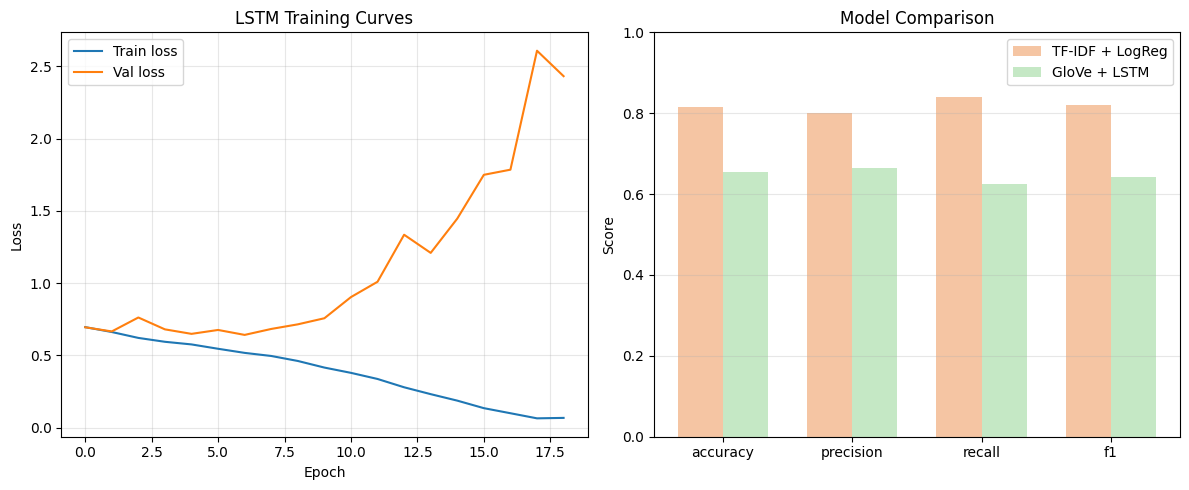


Improvement:
  accuracy: -0.162 (-19.9%)
  precision: -0.138 (-17.2%)
  recall: -0.216 (-25.7%)
  f1: -0.177 (-21.6%)


In [23]:
# Comparison
comparison = pd.DataFrame({
    'TF-IDF + LogReg': baseline_results,
    'GloVe + LSTM': lstm_results
}).T

print("\n" + "=" * 60)
print("BASELINE vs UPGRADE")
print("=" * 60)
print(comparison.round(3))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
axes[0].plot(train_losses, label='Train loss')
axes[0].plot(val_losses, label='Val loss')
axes[0].set_title("LSTM Training Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Metrics comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.35

baseline_vals = [baseline_results[m] for m in metrics]
lstm_vals = [lstm_results[m] for m in metrics]

axes[1].bar(x - width/2, baseline_vals, width, label='TF-IDF + LogReg', color='#f5c5a3')
axes[1].bar(x + width/2, lstm_vals, width, label='GloVe + LSTM', color='#c5e8c5')
axes[1].set_ylabel("Score")
axes[1].set_title("Model Comparison")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nImprovement:")
for metric in metrics:
    improvement = lstm_results[metric] - baseline_results[metric]
    pct_improvement = (improvement / baseline_results[metric] * 100) if baseline_results[metric] > 0 else 0
    print(f"  {metric}: {improvement:+.3f} ({pct_improvement:+.1f}%)")

**Cell 11 — Inference Function**

In [24]:
def predict_sentiment(text, model, word_vectors, device, max_length=50):
    """Predict sentiment for a single review."""
    model.eval()

    # Tokenise and embed
    tokens = text.lower().split()[:max_length]
    embeddings = []

    for word in tokens:
        if word in word_vectors:
            embeddings.append(word_vectors[word])
        else:
            embeddings.append(np.zeros(word_vectors.vector_size))

    # Pad
    while len(embeddings) < max_length:
        embeddings.append(np.zeros(word_vectors.vector_size))

    X = torch.FloatTensor(np.array(embeddings[:max_length])).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(X)
        proba = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1).item()

    return {
        'prediction': 'Positive' if pred == 1 else 'Negative',
        'confidence': proba[0, pred].item(),
        'negative_score': proba[0, 0].item(),
        'positive_score': proba[0, 1].item()
    }

# Test on new reviews
test_reviews = [
    "This movie was amazing, I loved it!",
    "Terrible film, waste of time",
    "Not bad, but could be better",
]

print("=" * 60)
print("INFERENCE ON NEW REVIEWS")
print("=" * 60)

for review in test_reviews:
    result = predict_sentiment(review, model, word_vectors, device)
    print(f"\nReview: {review}")
    print(f"  Prediction: {result['prediction']} (confidence: {result['confidence']:.2%})")
    print(f"  Scores: Negative={result['negative_score']:.3f}, Positive={result['positive_score']:.3f}")

INFERENCE ON NEW REVIEWS

Review: This movie was amazing, I loved it!
  Prediction: Positive (confidence: 99.58%)
  Scores: Negative=0.004, Positive=0.996

Review: Terrible film, waste of time
  Prediction: Positive (confidence: 99.59%)
  Scores: Negative=0.004, Positive=0.996

Review: Not bad, but could be better
  Prediction: Positive (confidence: 99.58%)
  Scores: Negative=0.004, Positive=0.996


**Cell 12 — Summary**

In [25]:
print("""
PHASE 2 CAPSTONE - SENTIMENT ANALYSER COMPLETE

What was built:
  ✓ Baseline: TF-IDF + Logistic Regression
  ✓ Upgrade: GloVe embeddings + PyTorch LSTM
  ✓ Evaluation: Metrics, comparison, error analysis
  ✓ Inference: Function to predict on new reviews

Key learnings:
  • Data pipeline: load → split → preprocess → vectorise
  • Two feature representations: sparse (TF-IDF) vs dense (embeddings)
  • Two models: classical (LogReg) vs neural (LSTM)
  • Proper evaluation: accuracy, precision, recall, F1, confusion matrix
  • No data leakage: fit vectoriser on train only

Next steps for production:
  1. Test on real IMDB/Amazon dataset (thousands of reviews)
  2. Optimize LSTM (bidirectional, attention, tuning)
  3. Try pre-trained models (BERT fine-tuning in Phase 3)
  4. Deploy with Gradio or FastAPI
  5. Document in GitHub README
""")


PHASE 2 CAPSTONE - SENTIMENT ANALYSER COMPLETE

What was built:
  ✓ Baseline: TF-IDF + Logistic Regression
  ✓ Upgrade: GloVe embeddings + PyTorch LSTM
  ✓ Evaluation: Metrics, comparison, error analysis
  ✓ Inference: Function to predict on new reviews

Key learnings:
  • Data pipeline: load → split → preprocess → vectorise
  • Two feature representations: sparse (TF-IDF) vs dense (embeddings)
  • Two models: classical (LogReg) vs neural (LSTM)
  • Proper evaluation: accuracy, precision, recall, F1, confusion matrix
  • No data leakage: fit vectoriser on train only

Next steps for production:
  1. Test on real IMDB/Amazon dataset (thousands of reviews)
  2. Optimize LSTM (bidirectional, attention, tuning)
  3. Try pre-trained models (BERT fine-tuning in Phase 3)
  4. Deploy with Gradio or FastAPI
  5. Document in GitHub README

